In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [3]:
import numpy as np
import matplotlib.pyplot as plt
# import pandas as pd
# from sklearn.neighbors import NearestNeighbors


centimeter = 1/2.54 # conversion from inch, for plotting

font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 6}

# matplotlib.rc('font', **font)



## A simulation of intra-v-extracellular signal:



In [4]:
%pip install sympy

from sympy import *

h,k,z,r,m,um = symbols('h k z r m μm') # slice-height/2, helper-height, z, cell radius

vol_sphere = 4/3*pi*r**3
vol_cap = (pi*k**2)/3*(3*r-k) #from 0 to 2*r

area_base_cap = pi*(r**2-(r-k)**2) #from 0 to 2*r

vol_segment = simplify(integrate(area_base_cap,(k,z+r-h,z+r+h))) # segment centered at 0,from -h to h

vol_fp_sphere = 2*h*pi*r**2
vol_fp_cap = area_base_cap*h*2

# case r<h;  z=vertical position of center of ball:

# ball entirely in slice, from z=0 to z=h-r:
cell_in_slice = integrate(vol_sphere,(z,0,h-r))

# ball moving out of slice:
cell_moving_out = integrate(vol_cap,(k,0,r*2))

# the largest diameter of the sphere is inside the slice, from z=0 to z=h:
cell_max_in_slice_fp = integrate(vol_fp_sphere,(z,0,h))

# the cell is moving out of the slice:
cell_moving_out_fp = integrate(vol_fp_cap,(k,0,r*2))

cell_signal = simplify(cell_in_slice+cell_moving_out)
fp_signal = simplify(cell_max_in_slice_fp+cell_moving_out_fp)
purity_r_below_h = (cell_signal/fp_signal)*2

# plotting.plot3d(purity_r_below_h,(r,0,10),(h,0,10))


# case r>h;  z=vertical position of center of ball:

cell_cut_top_bottom = integrate(vol_segment,(z,0,r-h))
cell_cut_top = integrate(vol_cap,(k,0,2*h))
# cell_cut_top = integrate(vol_cap,(k,r-h,r*2))

purity_r_above_h = simplify(cell_cut_top_bottom+cell_cut_top)/fp_signal*2


purity_r_below_h

Note: you may need to restart the kernel to use updated packages.


4.0*r/(3*h + 4*r)

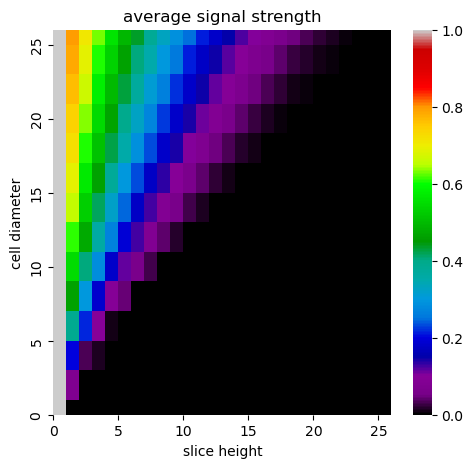

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig = plt.figure(figsize=(12,5))

ax1 = plt.subplot(121,facecolor='k')
# ax2 = plt.subplot(122,facecolor='k')

hs = np.arange(1,27)
rs = np.arange(1,20)
ds = np.arange(1,27,1)


def simulate_purity(ds,hs):
    
    # densities = []  
    # signal_list = []
    # footprint_list = []
    
    observation_list = []
    observation_list_full_signal = []
    
    for h in hs:

        # densities.append([])
        # signal_list.append([])
        # footprint_list.append([])
        observation_list.append([])
        observation_list_full_signal.append([])
        
        for d in ds:
            
            r = d//2

            span = np.linspace(-r,r,2*r+1)

            X,Y,Z = np.meshgrid(np.linspace(-r,r,2*r+1),np.linspace(-r,r,2*r+1),np.linspace(0,h,h))
            
            # density = []
            
            # footprints = []
            # signals = []
            observations = []
            observations_full_signal = []
            
            for i,d in enumerate(range(-r-h-1,r+2,1)):
                sphere = (X**2+Y**2+(Z+d)**2)**0.5<=r
                
                # plt.figure()
                # plt.imshow(sphere.sum(0))
                
                if sphere.sum()>0:
                        
                    # footprint = (sphere.sum(-1)>0)*h
                    signal = sphere[sphere.sum(-1)>0]
                    
                    den = signal.sum(-1)/h
                    
                    # footprints.append(footprint.sum())
                    # signals.append(signal.sum())
                        
                    # density.append(np.mean(sphere[sphere.sum(-1)>0]/h))   
                    observations+=list(den)
                    observations_full_signal+=list(signal.mean(-1)==1)
            
                # print(f"{i+1}: {sphere.sum()}")
            # ax1.plot(np.arange(len(density))-r-(h//2),density,c=[0,1-r/40,r/40])
            # ax2.plot(np.arange(len(purity))-r-(h//2),purity,c=[0.8,1-r/40,0])
                
                
            # signal_list[-1].append(np.sum(signals))
            # footprint_list[-1].append(np.sum(footprints))
                               
            # densities[-1].append(np.mean(density))
            observation_list[-1].append(np.mean(observations))
            observation_list_full_signal[-1].append(np.mean(observations_full_signal))

    return np.array(observation_list),np.array(observation_list_full_signal)

observations,observations_full_signal = simulate_purity(ds,hs)
sns.heatmap(observations_full_signal.T,ax=ax1,cmap='nipy_spectral',vmin=0,vmax=1,
            xticklabels=5,yticklabels=5,cbar=True)

ax1.set_xlabel('slice height')
ax1.set_ylabel('cell diameter')
ax1.set_title('average signal strength')
ax1.invert_yaxis()

ax1.set_xticks(ax1.get_xticks()-0.5,ax1.get_xticklabels())
ax1.set_yticks(ax1.get_yticks()-0.5,ax1.get_yticklabels())

# plt.savefig('publication/simulations/signal_strength_simulation.svg',dpi=300)


In [9]:
# Modeling contaminated vs. pure signal ratio;

from sympy import *

h,k,z,r,m,d,um = symbols('h k z r m d μm') # slice-height/2, helper-height, z, cell radius

vol_sphere = 4/3*pi*r**3
vol_cap = (pi*k**2)/3*(3*r-k) #from 0 to 2*r

area_base_cap = pi*(r**2-(r-k)**2) #from 0 to 2*r

vol_segment = simplify(integrate(area_base_cap,(k,z+r-h,z+r+h))) # segment centered at 0,from -h to h

vol_fp_sphere = 2*h*pi*r**2
vol_fp_cap = area_base_cap*h*2

# calculate overall footprint:
cell_max_in_slice_fp = vol_fp_sphere 
# the cell is moving out of the slice:
cell_moving_out_fp = integrate(area_base_cap,(k,0,r*2))

# # cell_signal = simplify(cell_in_slice+cell_moving_out)
fp_signal = simplify(cell_max_in_slice_fp+cell_moving_out_fp) 

# case r>h;  z=vertical position of center of ball: 

fp_clean_signal = integrate(area_base_cap,(k,0,r-h))*2  
clean_signal_ratio = simplify(fp_clean_signal/(fp_signal))
print(latex(clean_signal_ratio))
clean_signal_ratio

\frac{\left(h - r\right)^{2} \left(h + 2 r\right)}{r^{2} \cdot \left(3 h + 2 r\right)}


(h - r)**2*(h + 2*r)/(r**2*(3*h + 2*r))

In [10]:
clean_signal_ratio_d = simplify(clean_signal_ratio.subs(r,d))
purity_r_below_h_d = simplify(purity_r_below_h.subs(r,d/2))
clean_signal_ratio_d

(d - h)**2*(2*d + h)/(d**2*(2*d + 3*h))

FileNotFoundError: [Errno 2] No such file or directory: './simulations/signal_strength_simulation.svg'

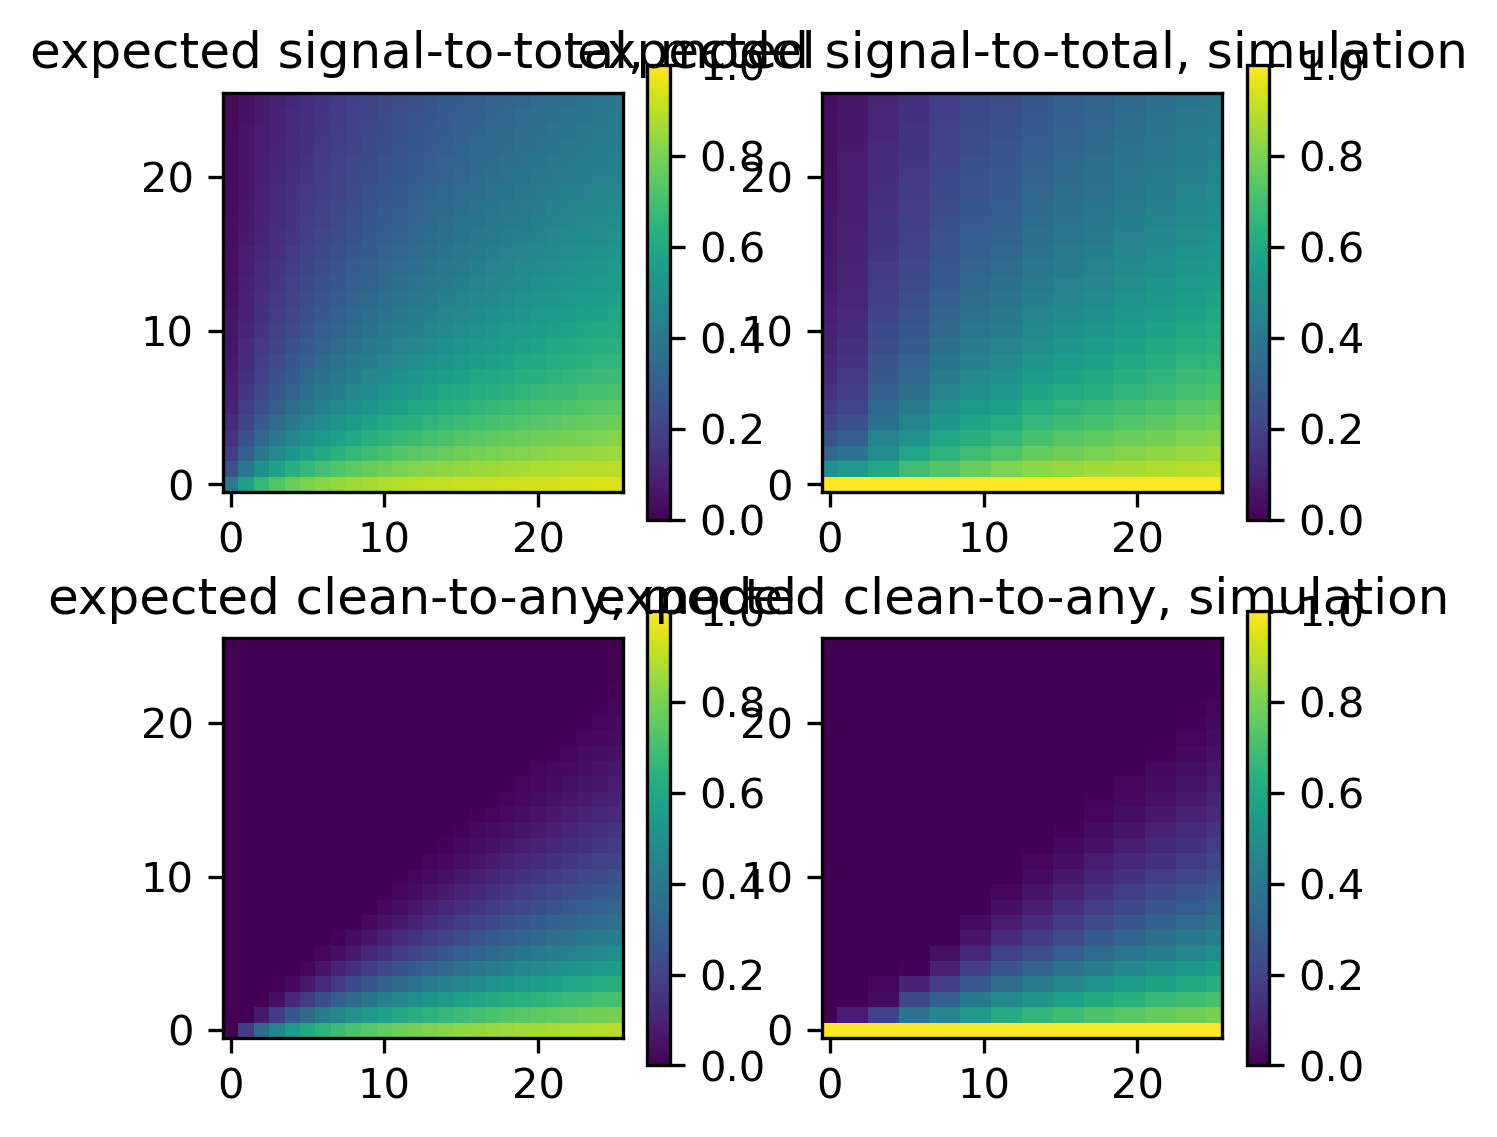

In [17]:

# rs = np.linspace(0,1,30)

D,H = np.meshgrid(ds,hs)

purity_np = lambdify((d,h),purity_r_below_h_d,modules='numpy')
clean_signal_ratio_np = lambdify((d,h),clean_signal_ratio_d,modules='numpy')


plt.figure(figsize=(12*centimeter,11*centimeter),dpi=300)

plt.subplot(221)
plt.title('expected signal-to-total, model')
plt.imshow((purity_np(D,H)),cmap='viridis',vmin=0,vmax=1)
plt.gca().invert_yaxis()
plt.colorbar()


plt.subplot(222)
plt.title('expected signal-to-total, simulation')
plt.imshow(observations,cmap='viridis',vmin=0,vmax=1)

plt.colorbar()
plt.gca().invert_yaxis()    
''

plt.subplot(223)
plt.title('expected clean-to-any, model')
plt.imshow(clean_signal_ratio_np(D,H)*(D>H),cmap='viridis',vmin=0,vmax=1)
plt.colorbar()
plt.gca().invert_yaxis()

plt.subplot(224)
plt.title('expected clean-to-any, simulation')
plt.imshow(observations_full_signal,cmap='viridis',vmin=0,vmax=1)
plt.colorbar()
plt.gca().invert_yaxis()

plt.savefig('./simulations/signal_strength_simulation.svg',dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: './simulations/signal_spec_models.svg'

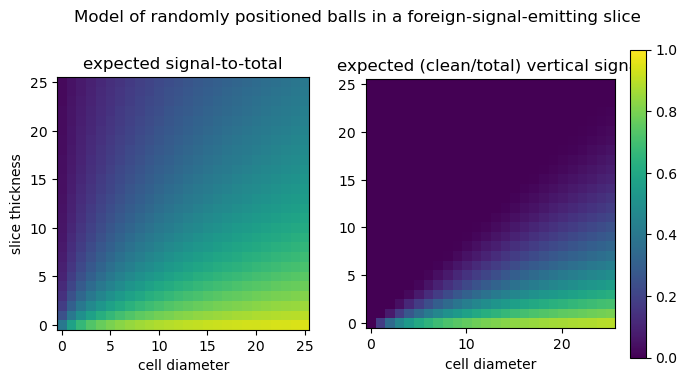

In [18]:
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as PathEffects

plt.figure(figsize=(8,4))

plt.suptitle("Model of randomly positioned balls in a foreign-signal-emitting slice")

gs = GridSpec(1, 2, width_ratios=[3, 3.7])


ax = plt.subplot(gs[0])
plt.title('expected signal-to-total')

plt.imshow(purity_np(D,H),cmap='viridis',vmin=0,vmax=1)
ax.invert_yaxis()
plt.ylabel('slice thickness')
plt.xlabel('cell diameter')
# txt_artist = plt.text(1,21,f"$s={latex(purity_r_above_h)}$",fontsize=14,color='w')
# txt_artist.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='k')])

ax = plt.subplot(gs[1])
plt.title('expected (clean/total) vertical signal')

plt.imshow((clean_signal_ratio_np(D,H)*(H<D)),cmap='viridis',vmin=0,vmax=1)
ax.invert_yaxis()
plt.colorbar()
plt.xlabel('cell diameter')
# txt_artist = plt.text(1,20,f"$s={latex(clean_signal_ratio)}$",fontsize=12,color='w')
# txt_artist.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='k')])

plt.savefig('./simulations/signal_spec_models.svg',dpi=300)

plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: './simulations/signal_purity_lines.svg'

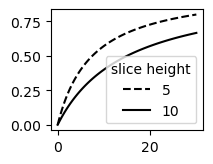

In [19]:
x = np.linspace(0,30,100)



fig,ax = plt.subplots(1,1,figsize=(5*centimeter,4*centimeter))

plt.plot(x,purity_np(x,5),'k--',label="5")
plt.plot(x,purity_np(x,10),'k',label="10")

plt.legend(title='slice height')

plt.savefig('./simulations/signal_purity_lines.svg',dpi=300)

fig,ax = plt.subplots(1,1,figsize=(5*centimeter,4*centimeter))

y = clean_signal_ratio_np(x,5)
y[x<5]=0
plt.plot(x,y,'k--',label="5")

y = clean_signal_ratio_np(x,10)
y[x<10]=0
plt.plot(x,y,'k',label="10")
plt.legend(title='slice height')

plt.savefig('./simulations/signal_clean_lines.svg',dpi=300)

[0.        2.0943951 4.1887902] [ 1.  -0.5 -0.5] [ 0.         0.8660254 -0.8660254]


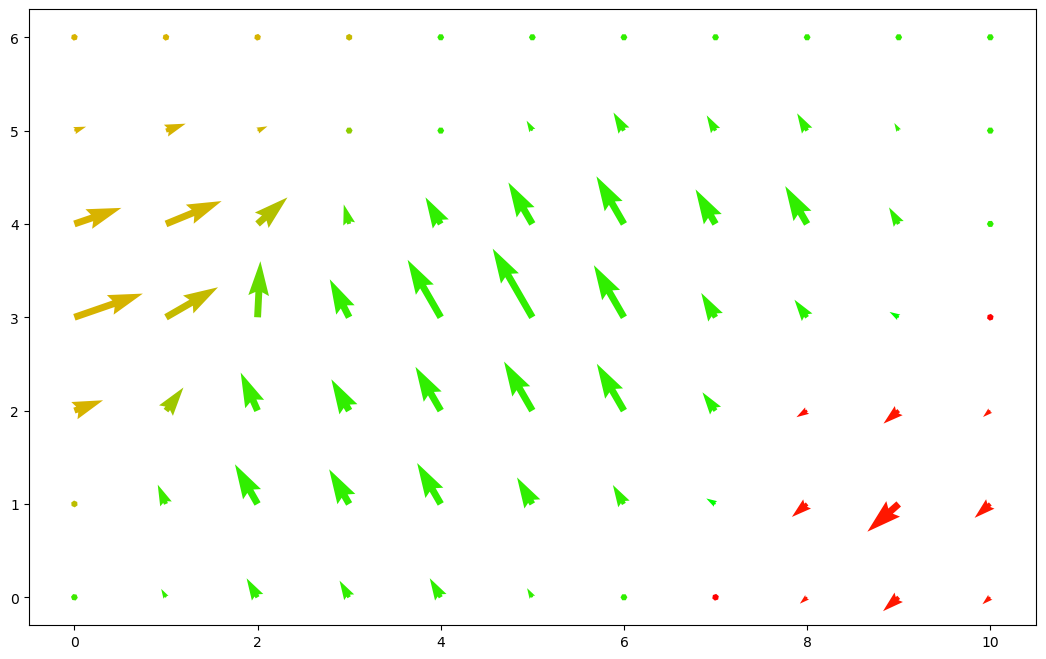

In [14]:
### create a 3d figurette to display the algorithm:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list('cmap',['red','orange','lime',])


cell_locations = np.array([[3, 0],[4, 1],
       [1, 4],[4, 6],[3, 2],[3, 4],[2, 6],[3, 5],[1, 2],[4, 8],
       [1, 9]])
cell_types=[0,0,1,1,1,1,1,1,1,1,2]
vf = np.zeros((7,11,3))

vf[cell_locations[:,0],cell_locations[:,1],cell_types] = 1

vf = gaussian_filter(vf,0.8)
vf_norm = vf.sum(-1)
vf/=vf_norm[:,:,None]

angles = np.linspace(0,2*np.pi,3,endpoint=False)#np.array( [np.pi / 2,7 * np.pi / 6,11 * np.pi / 6] )
x_ends = np.cos(angles)
y_ends = np.sin(angles)

print(angles,x_ends,y_ends)

u = (vf*x_ends[None,None]).mean(-1)
v = (vf*y_ends[None,None]).mean(-1)

uv_norm = np.sqrt(u**2+v**2)
u/=uv_norm
v/=uv_norm

plt.figure(figsize=(13,8))
# plt.subplot(121)
# plt.imshow(gaussian_filter(vf,1))

plt.subplot(111)
plt.quiver(*np.meshgrid(np.arange(vf.shape[1]),np.arange(vf.shape[0])),
           u*vf_norm,v*vf_norm,
           np.arctan2(v,u), 
           angles='uv',scale=6,cmap=cmap)#,vmin=0,vmax=3)

ax.set_aspect('equal')


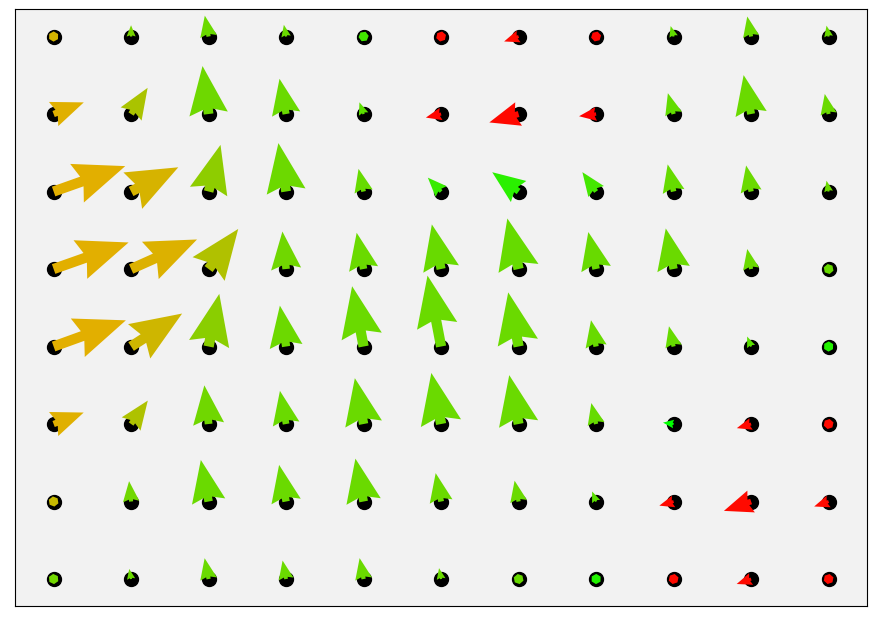

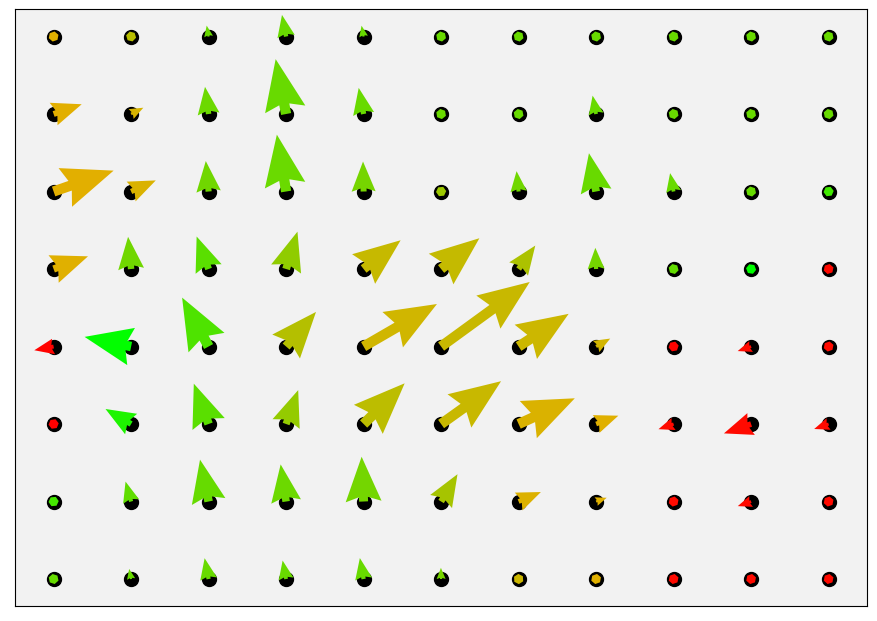

In [15]:
### create a 3d figurette to display the algorithm:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list('cmap',['red','orange','lime',])


green_cells_top = [[1, 4],[4, 6],[3, 2],[3, 4],[2, 6],[3, 5],[1, 2],[4, 8],[6,2],[5,3],[6,9]]
orange_cells_top = [[3, 0],[5, 0],[4, 1]]
red_cells_top = [[1, 9],[6,6]]

green_cells_bottom = [[1, 4],[3, 2],[3, 5],[1, 2],[5, 7],[6,3],[5,3]]
orange_cells_bottom = [[5, 0],[2, 6],[3, 5],[3,4]]
red_cells_bottom = [[2, 9],[3, 1]]

vf = np.zeros((8,11,3))


def quiver_vf(vf,scale=5):    
    vf_norm = vf.sum(-1)+0.01
    vf/=vf_norm[:,:,None]

    angles = np.linspace(0,2*np.pi,3,endpoint=False)#np.array( [np.pi / 2,7 * np.pi / 6,11 * np.pi / 6] )
    x_ends = np.cos(angles)
    y_ends = np.sin(angles)

    u = (vf*x_ends[None,None]).mean(-1)
    v = (vf*y_ends[None,None]).mean(-1)

    uv_norm = np.sqrt(u**2+v**2)
    u/=uv_norm
    v/=uv_norm

    plt.figure(figsize=(11,8))
    # plt.subplot(121)
    # plt.imshow(gaussian_filter(vf,1))

    ax = plt.subplot(111,facecolor=[0.95,0.95,0.95])
    plt.scatter(*np.meshgrid(np.arange(vf.shape[1]),np.arange(vf.shape[0])),c='k',s=100)
    plt.quiver(*np.meshgrid(np.arange(vf.shape[1]),np.arange(vf.shape[0])),
            u*vf_norm,v*vf_norm,
            np.arctan2(v,u), 
            angles='uv',scale=scale,cmap=cmap,
            width=0.012,headwidth=4)#,vmin=0,vmax=3)

    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-0.5,10.5)



vf_top = np.zeros((8,11,3))
for i, cell_idcs in enumerate([orange_cells_top,green_cells_top,red_cells_top]):
    vf_top[[c[0] for c in cell_idcs],[c[1] for c in cell_idcs],i] = 1
    
vf_top = gaussian_filter(vf_top,0.8)
vf_top[...,-1]/=2
quiver_vf(vf_top)

vf_bottom = np.zeros((8,11,3))
for i, cell_idcs in enumerate([orange_cells_bottom,green_cells_bottom,red_cells_bottom]):
    vf_bottom[[c[0] for c in cell_idcs],[c[1] for c in cell_idcs],i] = 1
    
vf_bottom = gaussian_filter(vf_bottom,0.8)
vf_bottom[...,-1]/=2

quiver_vf(vf_bottom)


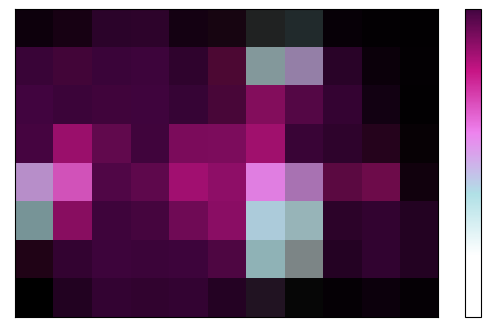

In [16]:
cmap = LinearSegmentedColormap.from_list('rolands_pride', ['#430541','mediumvioletred','violet','powderblue','white','white'][::-1])

cosine_similarity_top_bottom = ((vf_top/np.sqrt((vf_top**2).sum(-1))[:,:,None])*(vf_bottom/np.sqrt((vf_bottom**2).sum(-1))[:,:,None])).sum(-1)
cosine_similarity_top_bottom[:,:6]**=0.3
cosine_similarity_top_bottom[:,8:]**=0.3

signal = (vf_top.sum(-1)+vf_bottom.sum(-1))

plt.figure(figsize=(7,4))
ax = plt.subplot(111,facecolor='k')
plt.imshow(cosine_similarity_top_bottom,cmap=cmap,alpha=(signal/signal.max())**4)
ax.invert_yaxis()

plt.xticks([])
plt.yticks([])

cbar = plt.colorbar()
cbar.set_ticks([])